In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)


from imblearn.over_sampling import SMOTE 


### Observation
The required libraries were imported for data manipulation, visualization, model training, evaluation, and class imbalance handling using SMOTE.


In [7]:
df = pd.read_csv("data/raw/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Separate Features and Target

In [9]:
X = df.drop( "Class", axis = 1)

y  = df["Class"]

print(X.shape)
print(y.shape)

(284807, 30)
(284807,)


### Observation
The predictor variables were separated from the target variable. The feature matrix contains transaction information, while the target variable indicates whether each transaction is fraudulent or legitimate.

### Original Class Distribution

In [12]:
print(y.value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


###  Observation
The dataset is highly imbalanced, with legitimate transactions significantly outnumbering fraudulent transactions. This imbalance can bias machine learning models toward the majority class.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)


(227845, 30)
(56962, 30)


###  Observation

The dataset was divided into training and testing sets using stratified sampling to preserve the original fraud-to-normal ratio in both subsets.

### Apply SMOTE (Synthetic Minority Oversampling Technique)

In [14]:
smote = SMOTE(random_state=42) 

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)




### Observation
SMOTE was applied to the training data to generate synthetic fraud examples. This helps balance the classes and provides the model with more opportunities to learn fraud patterns.

### Check New Class Distribution

In [15]:
print(y_train_smote.value_counts())

Class
0    227451
1    227451
Name: count, dtype: int64


### Observation
After applying SMOTE, the minority and majority classes are balanced. The model can now learn from an equal number of fraudulent and legitimate transactions.

### Visualize Before vs After SMOTE

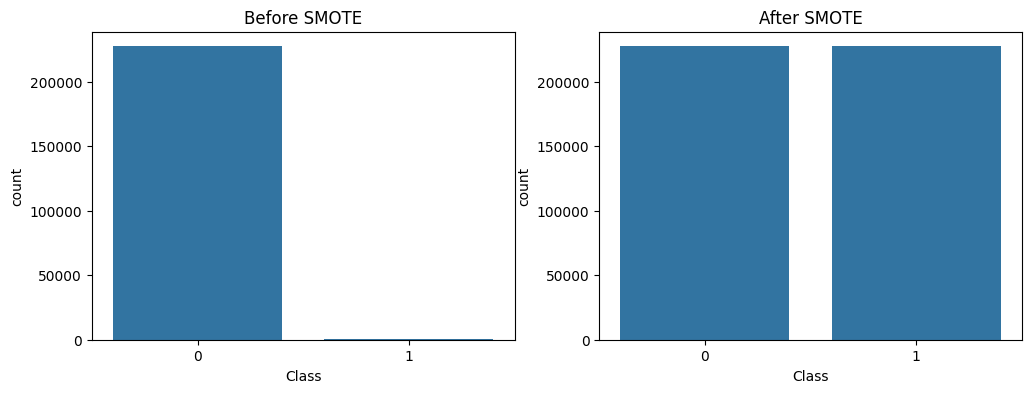

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title("Before SMOTE")

sns.countplot(x=y_train_smote, ax=axes[1])
axes[1].set_title("After SMOTE")

plt.show()

### Observation
The visualization confirms that SMOTE successfully balanced the training dataset by increasing the number of fraud observations.

### Train Logistic Regression on SMOTE Data

In [20]:
model_smote = LogisticRegression(max_iter=8000,random_state=42)

model_smote.fit(X_train_smote, y_train_smote)



C:\python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 8000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=8000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",8000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

### Observation
A Logistic Regression model was trained using the balanced dataset generated by SMOTE. The model now has access to a substantially larger number of fraud examples during training.

### Predictions

In [21]:
y_pred_smote = model_smote.predict(X_test)

y_prob_smote = model_smote.predict_proba(X_test)[:,1]



### Observation
Predictions and fraud probabilities were generated for the unseen test dataset to evaluate model performance.

### Classification Report

In [22]:
print(classification_report(
    y_test,
    y_pred_smote
))



              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.13      0.90      0.23        98

    accuracy                           0.99     56962
   macro avg       0.57      0.94      0.61     56962
weighted avg       1.00      0.99      0.99     56962



### Observation
After applying SMOTE, the Logistic Regression model achieved a recall of 90% on the fraud class, compared to 65% in the baseline model. This indicates that substantially fewer fraudulent transactions were missed. However, precision decreased significantly to 13%, suggesting that the model generated a large number of false fraud alerts. The results highlight the trade-off between fraud detection capability and false positive rates when handling class imbalance.

### Confusion Matrix

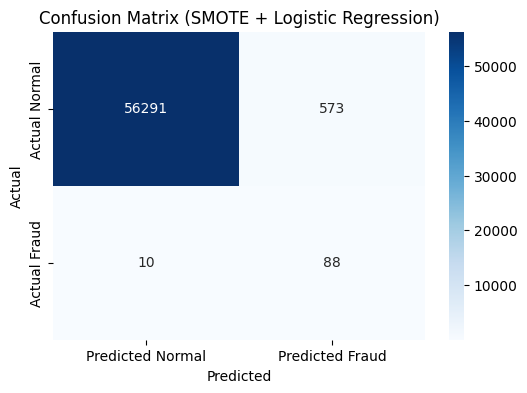

In [23]:
cm = confusion_matrix(
    y_test,
    y_pred_smote
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Predicted Normal",
        "Predicted Fraud"
    ],
    yticklabels=[
        "Actual Normal",
        "Actual Fraud"
    ]
)

plt.title(
    "Confusion Matrix (SMOTE + Logistic Regression)"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Observation
The confusion matrix demonstrates that applying SMOTE significantly improved fraud detection performance. The model correctly identified 88 fraudulent transactions compared to 64 in the baseline model, reducing missed fraud cases from 34 to 10. However, this improvement came at the cost of a substantial increase in false positives, rising from 14 to 573. These results highlight the trade-off between maximizing fraud detection recall and minimizing false fraud alerts.

### ROC-AUC Score

In [26]:
auc_smote = roc_auc_score(y_test,y_prob_smote)

print(
    "ROC-AUC Score:",
    auc_smote
)

ROC-AUC Score: 0.9774860246574713


### Observation
The SMOTE-enhanced Logistic Regression model achieved a ROC-AUC score of 0.9775, improving upon the baseline model's ROC-AUC of 0.9525. This indicates a stronger ability to distinguish between fraudulent and legitimate transactions across all classification thresholds. Although precision decreased due to an increase in false positives, the higher ROC-AUC suggests that the model learned more effective fraud-related patterns after addressing class imbalance with SMOTE.

### ROC Curve

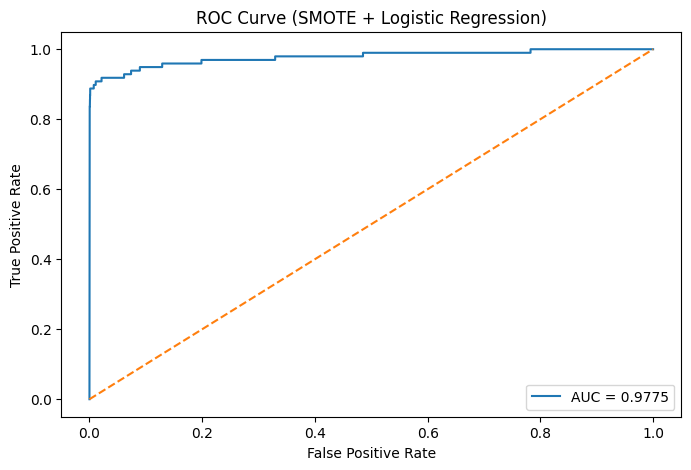

In [27]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_smote
)

plt.figure(figsize=(8,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_smote:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve (SMOTE + Logistic Regression)"
)

plt.legend()

plt.show()

### Observation
The ROC curve lies very close to the top-left corner of the plot and remains substantially above the random-classification line. This indicates that the SMOTE-enhanced Logistic Regression model has excellent discriminatory power and can effectively distinguish between fraudulent and legitimate transactions. The ROC-AUC score of 0.9775 demonstrates improved class separation compared to the baseline Logistic Regression model, suggesting that SMOTE helped the model learn fraud-related patterns more effectively

### Baseline vs SMOTE Comparison

In [29]:
comparison = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Baseline Logistic": [
        0.82,
        0.65,
        0.73,
        0.9525
    ],
    "SMOTE Logistic": [
        0.13,
        0.90,
        0.23,
        0.9775
    ]
})

comparison

,Metric,Baseline Logistic,SMOTE Logistic
0,Precision,0.8200,0.1300
1,Recall,0.6500,0.9000
2,F1-Score,0.7300,0.2300
3,ROC-AUC,0.9525,0.9775


### Observation
A comparison of the baseline Logistic Regression model and the SMOTE-enhanced model reveals a significant trade-off. Applying SMOTE improved fraud recall from 65% to 90% and increased ROC-AUC from 0.9525 to 0.9775, indicating better discrimination between fraudulent and legitimate transactions. However, precision decreased substantially from 82% to 13%, reflecting a large increase in false positive predictions. These results demonstrate the balance that must be achieved between maximizing fraud detection and minimizing unnecessary fraud alerts.

### End-of-Notebook Conclusion

### Observation
SMOTE successfully addressed the severe class imbalance present in the dataset and significantly improved the model's ability to detect fraudulent transactions. While the increase in recall is desirable for fraud detection applications, the reduction in precision highlights the cost of generating additional false alarms. Future models such as Random Forest and XGBoost will be evaluated to determine whether they can achieve higher recall while maintaining better precision.